In [1]:
import numpy
import shap

print("NumPy:", numpy.__version__)
print("SHAP :", shap.__version__)

NumPy: 1.26.4
SHAP : 0.45.1


In [2]:
# ============================================================
# Notebook 06: SHAP Explainability
# AI Financial Risk Intelligence Platform
# ============================================================

from pathlib import Path
import pandas as pd
import shap

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

# ------------------------------------------------------------
# Load Dataset
# ------------------------------------------------------------

PROJECT_ROOT = Path(r"C:\Users\user\machine-learning-models-practical\AIML Engineer Training Series\AI_Financial_Risk_Intelligence_Platform")

DATA_PATH = PROJECT_ROOT / "data" / "raw" / "german.data"

column_names = [
    "status", "duration", "credit_history", "purpose", "credit_amount",
    "savings", "employment_duration", "installment_rate", "personal_status_sex",
    "other_debtors", "present_residence", "property", "age",
    "other_installment_plans", "housing", "existing_credits", "job",
    "people_liable", "telephone", "foreign_worker", "target"
]

df = pd.read_csv(
    DATA_PATH,
    sep=r"\s+",
    header=None,
    names=column_names
)

df["target"] = df["target"].map({1: 0, 2: 1})

# ------------------------------------------------------------
# Features and Target
# ------------------------------------------------------------

X = df.drop(columns="target")
y = df["target"]

# ------------------------------------------------------------
# Train/Test Split
# ------------------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# ------------------------------------------------------------
# Feature Types
# ------------------------------------------------------------

categorical_cols = X_train.select_dtypes(include="object").columns.tolist()
numerical_cols = X_train.select_dtypes(exclude="object").columns.tolist()

# ------------------------------------------------------------
# Preprocessor
# ------------------------------------------------------------

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols)
    ]
)

# ------------------------------------------------------------
# Pipeline
# ------------------------------------------------------------

pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LogisticRegression(max_iter=1000, random_state=42))
    ]
)

pipeline.fit(X_train, y_train)

print("Pipeline trained successfully")

Pipeline trained successfully


In [3]:
# ============================================================
# Prepare Data for SHAP
# ============================================================

# Transform training and test data
X_train_transformed = pipeline.named_steps["preprocessor"].transform(X_train)
X_test_transformed = pipeline.named_steps["preprocessor"].transform(X_test)

# Get feature names after preprocessing
feature_names = pipeline.named_steps["preprocessor"].get_feature_names_out()

print("Transformed Train Shape:", X_train_transformed.shape)
print("Transformed Test Shape :", X_test_transformed.shape)
print("Number of Feature Names:", len(feature_names))

Transformed Train Shape: (800, 61)
Transformed Test Shape : (200, 61)
Number of Feature Names: 61


In [4]:
# ============================================================
# Create SHAP Explainer
# ============================================================

model = pipeline.named_steps["model"]

explainer = shap.LinearExplainer(model, X_train_transformed)

shap_values = explainer.shap_values(X_test_transformed)

print("SHAP values generated successfully")
print(shap_values.shape)

SHAP values generated successfully
(200, 61)


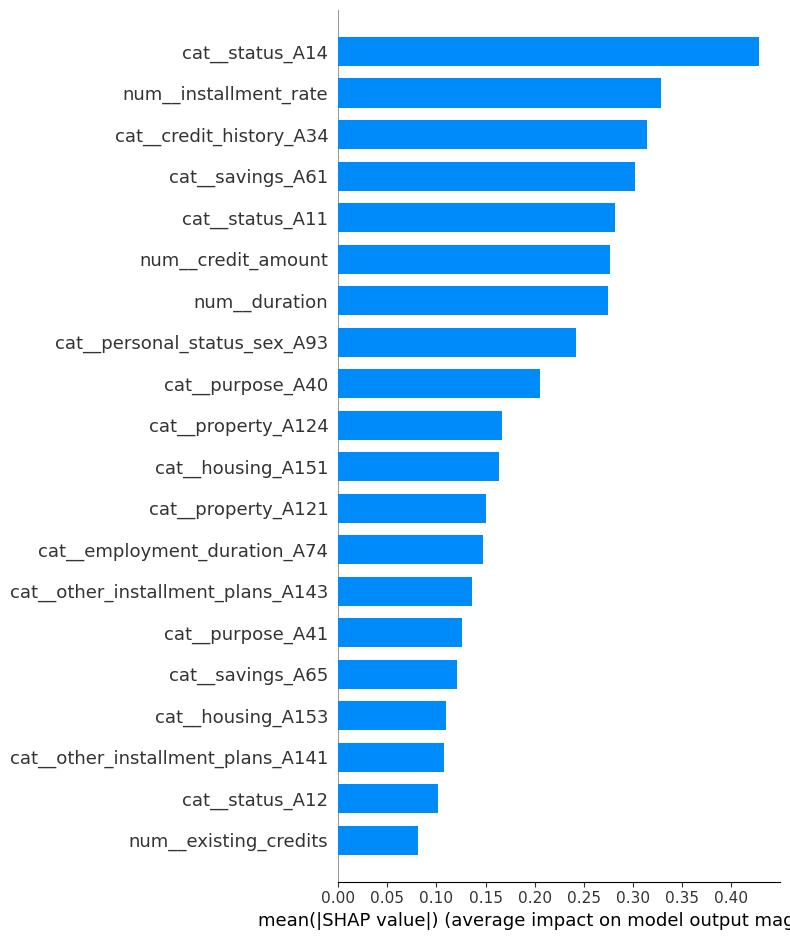

In [5]:
# ============================================================
# Global Feature Importance
# ============================================================

shap.summary_plot(
    shap_values,
    X_test_transformed,
    feature_names=feature_names,
    plot_type="bar"
)

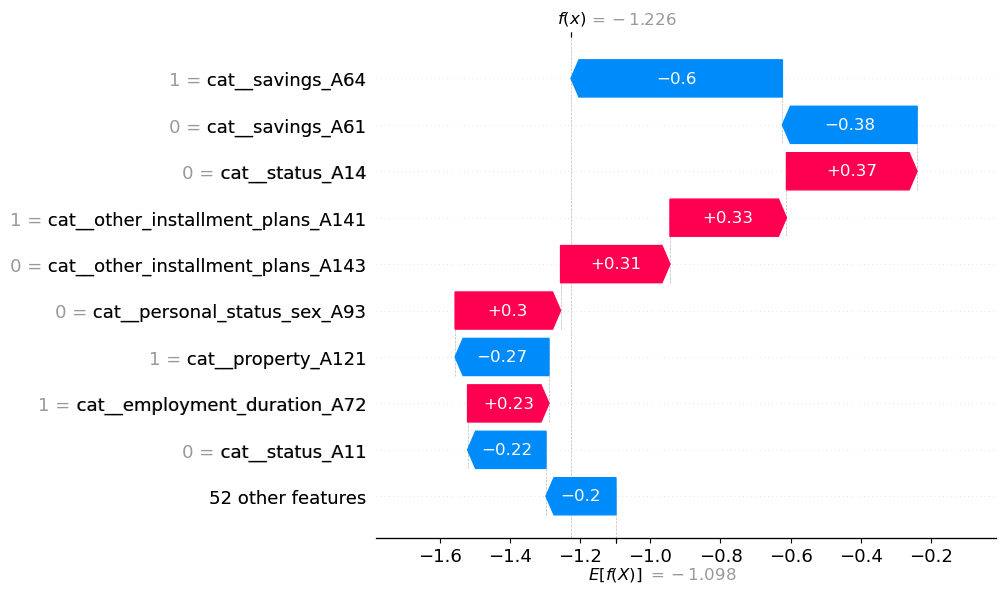

In [6]:
# ============================================================
# Explain a Single Customer
# ============================================================

customer_index = 0   # first customer in the test set

explanation = shap.Explanation(
    values=shap_values[customer_index],
    base_values=explainer.expected_value,
    data=X_test_transformed[customer_index],
    feature_names=feature_names
)

shap.plots.waterfall(explanation, max_display=10)

## SHAP Local Explanation

A SHAP waterfall plot was generated for an individual applicant to explain the prediction made by the Logistic Regression model.

The strongest factors reducing risk were related to **savings** and **property**, while **status**, **installment-plan categories**, and **employment duration** increased the predicted risk.

Overall, the negative SHAP contributions outweighed the positive contributions, leading the model toward the **Good Credit (target = 0)** prediction.

This demonstrates that the model can provide **transparent, customer-level explanations**, which is important for financial institutions that require interpretable AI systems for credit approval decisions.
